
`Práctica Nº 3 - Aprendizaje Profundo`



#**SEGMENTACIÓN SEMÁNTICA MULTICLASE**

##*DataSet: Racimos de uva*

### 00. Librerias

In [1]:
!pip install fastai==2.8.1 -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.3/235.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from fastai.basics import *
from fastai.vision import models
from fastai.vision.all import *
from fastai.metrics import *
from fastai.data.all import *
from fastai.callback import *
from pathlib import Path
import random
import numpy as np
import PIL
from PIL import Image
import torchvision.transforms as transforms
import torch

### 01. DataSet

In [77]:
%%capture
!wget https://www.dropbox.com/s/uknzc914w311web/dataset.zip?dl=1 -O dataset.zip
!unzip -o dataset.zip

In [4]:
path = Path('dataset')
path_images = path / "Images"
path_labels = path / "Labels"

In [78]:
path.ls()

(#4) [Path('dataset/Images'),Path('dataset/codesAll.txt'),Path('dataset/Labels'),Path('dataset/codes.txt')]

In [79]:
codes = np.loadtxt(path / 'codesAll.txt', dtype=str)
codes

array(['Background', 'Leaves', 'Wood', 'Pole', 'Grape'], dtype='<U10')

In [80]:
train_imgs = get_image_files(path_images/'train')
test_imgs = get_image_files(path_images/'test')

print("Train:", len(train_imgs))
print("Test:", len(test_imgs))

Train: 66
Test: 14


### 02. Obteniendo mascara a partir de la imagen


In [81]:
def get_y_fn(x):
    return Path(str(x).replace("Images","Labels").replace("color","gt").replace(".jpg",".png"))

###03. Split train/test

In [82]:
test_name = "test"

def ParentSplitter(x):
    return Path(x).parent.name == test_name

###04. Augmentations

In [83]:
from albumentations import Compose, ShiftScaleRotate, OpticalDistortion, CLAHE

transforms_aug = Compose([
    ShiftScaleRotate(p=0.5),
    OpticalDistortion(p=0.3),
    CLAHE(p=0.3)
], p=1)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


###05. Transformación (imagen - mascara)

In [84]:
class SegmentationAlbumentationsTransform(ItemTransform):
    split_idx = 0

    def __init__(self, aug):
        self.aug = aug

    def encodes(self, x):
        img, mask = x
        aug = self.aug(image=np.array(img), mask=np.array(mask))
        return PILImage.create(aug["image"]), PILMask.create(aug["mask"])

In [85]:
transformPipeline = SegmentationAlbumentationsTransform(transforms_aug)

###06. Transformación multiclase

In [86]:
class TargetMaskConvertTransform(ItemTransform):

    def encodes(self, x):
        img, mask = x
        mask = np.array(mask)

        mask_clean = np.zeros_like(mask, dtype=np.uint8)

        # background
        mask_clean[mask == 0] = 0

        # leaves
        mask_clean[mask == 150] = 1

        # wood
        mask_clean[(mask == 29) | (mask == 25)] = 2

        # pole
        mask_clean[(mask == 76) | (mask == 74)] = 3

        # grape
        mask_clean[mask == 255] = 4

        return img, PILMask.create(mask_clean)

###07. DataBlock



> Train



In [87]:
trainDB = DataBlock(
    blocks=(ImageBlock, MaskBlock(codes)),
    get_items=partial(get_image_files, folders=['train']),
    get_y=get_y_fn,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=[Resize((480,640)), TargetMaskConvertTransform(), transformPipeline],
    batch_tfms=Normalize.from_stats(*imagenet_stats)
)



> Test



In [88]:
testDB = DataBlock(
    blocks=(ImageBlock, MaskBlock(codes)),
    get_items=partial(get_image_files, folders=['train','test']),
    get_y=get_y_fn,
    splitter=FuncSplitter(ParentSplitter),
    item_tfms=[Resize((480,640)), TargetMaskConvertTransform()],
    batch_tfms=Normalize.from_stats(*imagenet_stats)
)

###06. DataLoaders

In [89]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

In [90]:
bs = 2

trainDLS = trainDB.dataloaders(path_images, bs=bs)
testDLS = testDB.dataloaders(path_images, bs=bs)

###07. Visualizar datos

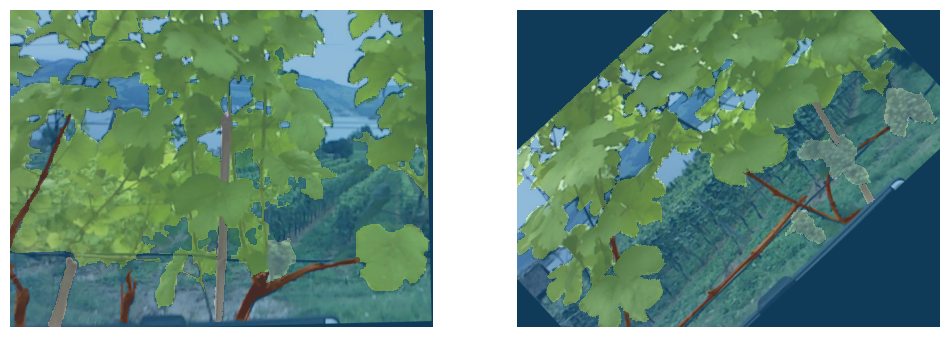

In [29]:
trainDLS.show_batch(figsize=(12,8), vmin=0, vmax=4)

###09. Modelo (resnet50 - multiclase)

In [91]:
learn = unet_learner(
    trainDLS,
    resnet50,
    metrics=[DiceMulti(), JaccardCoeffMulti()]
).to_fp16()



> Train



In [31]:
learn.fit_one_cycle(20, 3e-3)

epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,2.370215,2.202757,0.023499,0.012122,00:43
1,2.350146,2.150891,0.030593,0.016017,00:45
2,2.289169,2.038057,0.049040,0.026866,00:44
3,2.187398,1.885037,0.081725,0.049141,00:45
4,2.063898,1.746764,0.112483,0.074685,00:44
5,1.936767,1.629163,0.128075,0.089718,00:44
6,1.819163,1.528138,0.136008,0.096649,00:44
7,1.708351,1.440669,0.142057,0.100847,00:44
8,1.608294,1.365648,0.146882,0.103810,00:44
9,1.520257,1.295354,0.152046,0.106847,00:44




> Test



In [72]:
learn.dls = testDLS
learn.validate()

(#3) [0.7395351529121399,0.31711706843772947,0.2624515263389618]

###10. Guardar Modelo

In [92]:
aux = learn.model
aux = aux.cpu()

In [93]:
img = PILImage.create(path_images / 'train' / 'color_206.jpg')

transformer = transforms.Compose([
    transforms.Resize((480, 640)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

img = transformer(img).unsqueeze(0)
img = img.cpu()

In [94]:
traced_cell = torch.jit.trace(aux, (img))

traced_cell.save("unet_multiclass.pth")

print("Modelo guardado")

Modelo guardado


###11. Predicción / Inferencia

In [95]:
learn.model

DynamicUnet(
  (layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          


> Cargando un imagen de Test



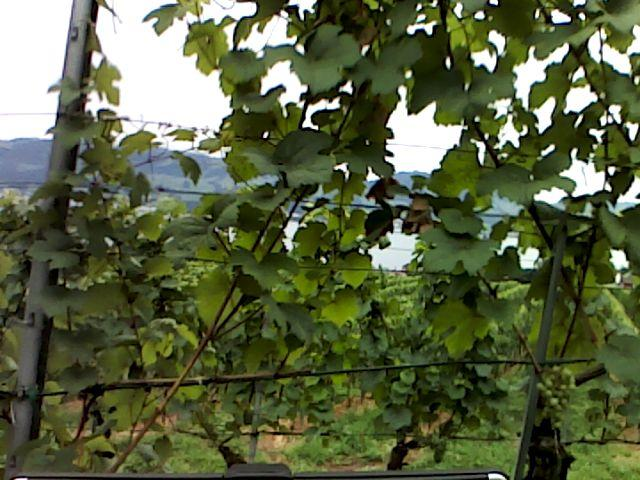

In [96]:
import PIL

img = PIL.Image.open('dataset/Images/test/color_154.jpg')
img

> Transformando imagen para inferencia

In [97]:
def transform_image(image):
    my_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
    return my_transforms(image).unsqueeze(0).to(device)

In [98]:
image = transforms.Resize((480,640))(img)
tensor = transform_image(image)



>  preparar imagen para inferencia



In [99]:
import torchvision.transforms as transforms
import PIL
import numpy as np
import matplotlib.pyplot as plt

img = PIL.Image.open('dataset/Images/test/color_154.jpg')
img_resized = transforms.Resize((480, 640))(img)

infer_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

x = infer_tfms(img_resized).unsqueeze(0)
x = x.to(learn.dls.device)



> Predicción con modelo entrenado



In [102]:
learn.model.eval()

x = x.float().cpu()
learn.model = learn.model.cpu()

with torch.no_grad():
    outputs = learn.model(x)

mask = torch.argmax(outputs, dim=1).squeeze().cpu().numpy()
print("Clases detectadas:", np.unique(mask))

Clases detectadas: [0 1 2 3 4]




> Visualización coloreada



In [103]:
def decode_segmap(mask):
    colors = np.array([
        [0, 0, 0],        # background
        [0, 255, 0],      # leaves
        [0, 0, 255],      # wood
        [255, 0, 0],      # pole
        [255, 255, 255]   # grape
    ], dtype=np.uint8)

    # asegurar que sea 2D
    mask = np.squeeze(mask).astype(np.uint8)

    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for i in range(len(colors)):
        rgb[:, :, 0][mask == i] = colors[i, 0]
        rgb[:, :, 1][mask == i] = colors[i, 1]
        rgb[:, :, 2][mask == i] = colors[i, 2]

    return rgb



> Carga y conversión de la mascara real



In [104]:
real_mask = PIL.Image.open('dataset/Labels/test/gt_154.png').convert("L")
real_mask = real_mask.resize((640, 480))
real_mask = np.array(real_mask)

real_clean = np.zeros_like(real_mask, dtype=np.uint8)
real_clean[real_mask == 0] = 0
real_clean[real_mask == 150] = 1
real_clean[(real_mask == 29) | (real_mask == 25)] = 2
real_clean[(real_mask == 76) | (real_mask == 74)] = 3
real_clean[real_mask == 255] = 4



> Comparación



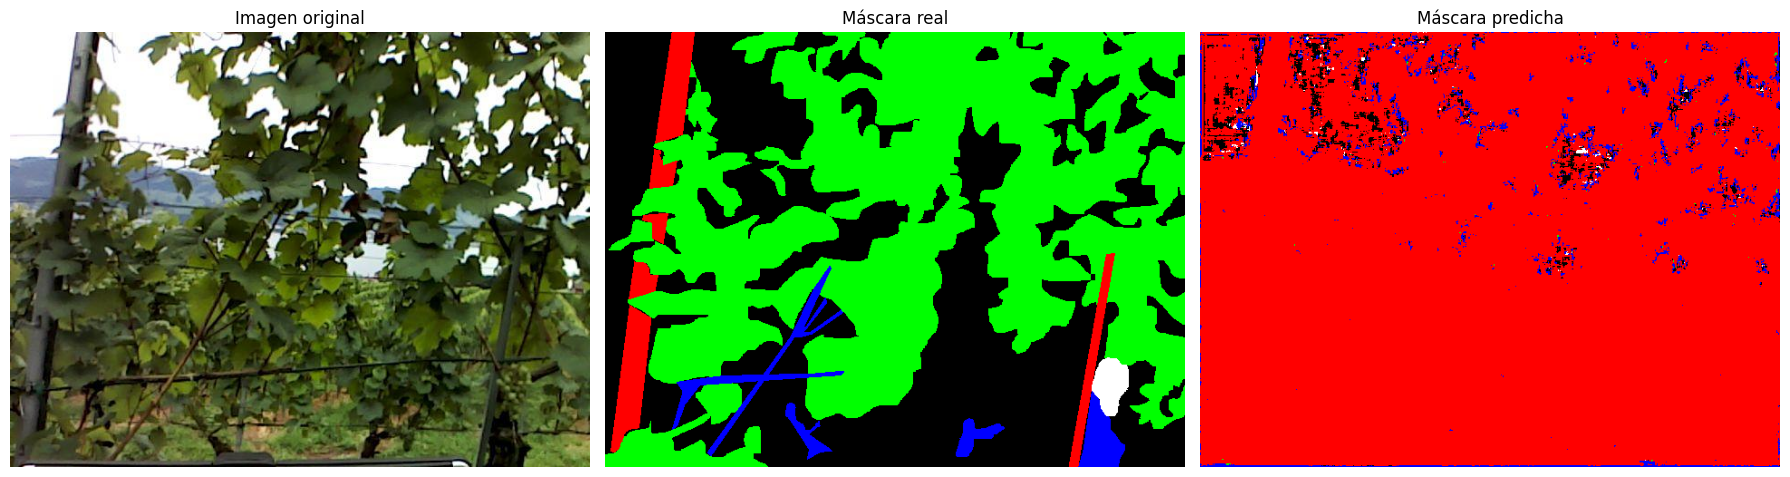

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_resized)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(decode_segmap(real_clean))
axes[1].set_title("Máscara real")
axes[1].axis("off")

axes[2].imshow(decode_segmap(mask))
axes[2].set_title("Máscara predicha")
axes[2].axis("off")

plt.tight_layout()
plt.show()

OPCIONALES :



> Learning rate


In [106]:
learn = unet_learner(
    trainDLS,
    resnet18,
    metrics=[DiceMulti(), JaccardCoeffMulti()]
).to_fp16()

Minimum/10: 3.31e-01, steepest point: 1.10e+00


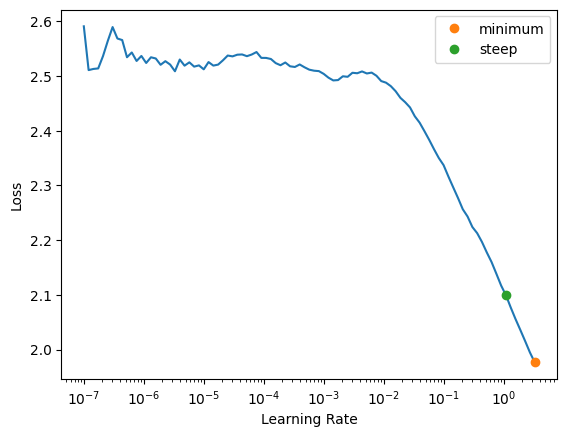

In [107]:
lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

In [63]:
learn.fit_one_cycle(20, lr_max=lr_steep)

epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,1.201965,0.991615,0.253226,0.185084,00:08
1,0.893242,0.756853,0.314728,0.245705,00:08
2,0.723650,1.402824,0.228637,0.163088,00:08
3,0.638403,1.023550,0.238934,0.172437,00:08
4,0.567233,0.509957,0.390189,0.321927,00:08
5,0.535739,0.651497,0.356092,0.282539,00:08
6,0.504407,0.521509,0.405249,0.325445,00:08
7,0.466218,0.463472,0.457869,0.363431,00:07
8,0.439208,0.502379,0.387780,0.320369,00:08
9,0.419425,0.416606,0.588088,0.459792,00:08




> Callbacks



In [64]:
cbs_list = [
    EarlyStoppingCallback(monitor='valid_loss', min_delta=0.01, patience=3),
    SaveModelCallback(monitor='valid_loss', fname='unet_best_model')
]

In [65]:
learn = unet_learner(
    trainDLS,
    resnet18,
    metrics=[DiceMulti(), JaccardCoeffMulti()],
    cbs=cbs_list
).to_fp16()

In [70]:
learn.dls = testDLS
learn.validate()

(#3) [0.7395351529121399,0.31711706843772947,0.2624515263389618]



> Unfreeze



In [67]:
learn = unet_learner(
    trainDLS,
    resnet18,
    metrics=[DiceMulti(), JaccardCoeffMulti()]
).to_fp16()

In [68]:
learn.fit_one_cycle(10, 3e-3)

epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,1.354556,1.372949,0.180761,0.117894,00:08
1,1.319647,1.237394,0.197576,0.135315,00:08
2,1.242007,1.051464,0.254826,0.186480,00:08
3,1.131131,0.885413,0.323290,0.268829,00:08
4,1.009612,0.759231,0.337259,0.290677,00:08
5,0.899489,0.690432,0.340235,0.295500,00:08
6,0.815332,0.660698,0.341960,0.298109,00:08
7,0.751423,0.645874,0.342985,0.299701,00:08
8,0.710881,0.641890,0.342555,0.298973,00:08
9,0.689297,0.641666,0.342192,0.298422,00:08


In [69]:
learn.unfreeze()
learn.fit_one_cycle(10, lr_max=slice(1e-5, 1e-4))

epoch,train_loss,valid_loss,dice_multi,jaccard_coeff_multi,time
0,0.655898,0.639836,0.342662,0.299112,00:08
1,0.662755,0.642745,0.340579,0.296025,00:08
2,0.656777,0.639332,0.343056,0.299730,00:08
3,0.652780,0.639327,0.342604,0.299044,00:08
4,0.657155,0.636032,0.342095,0.298290,00:08
5,0.654225,0.635722,0.343241,0.300052,00:08
6,0.652181,0.633967,0.342845,0.299412,00:08
7,0.652003,0.635855,0.342969,0.299634,00:08
8,0.648090,0.635296,0.343291,0.300129,00:08
9,0.646151,0.634857,0.342695,0.299210,00:08
